# Helmholtz equation

Copyright (C) 2018-2025 Samuel Groth and Jørgen S. Dokken

```{admonition} Download sources
:class: download
* {download}`Python script <./demo_helmholtz.py>`
* {download}`Jupyter notebook <./demo_helmholtz.ipynb>`
```
This demo illustrates how to:
- Create a complex-valued finite element formulation
In the following example, we will consider the Helmholtz equation solved
with both a complex valued and a real valued finite element formulation.

In the complex mode, the exact solution is a plane wave propagating at
an angle theta to the positive x-axis. Chosen for comparison with
results from Ihlenburg's book [Finite Element Analysis of Acoustic
Scattering, p138-139](https://doi.org/10.1007/0-387-22700-8_4).
In real mode, the exact solution corresponds to
the real part of the plane wave (a sin function which also solves the
homogeneous Helmholtz equation).

In [4]:
from mpi4py import MPI
from petsc4py import PETSc

import numpy as np

import ufl
from dolfinx.fem import (
    Expression,
    Function,
    assemble_scalar,
    dirichletbc,
    form,
    functionspace,
    locate_dofs_geometrical,
)
from dolfinx.fem.petsc import LinearProblem
from dolfinx.io import XDMFFile
from dolfinx.mesh import create_unit_square
from dolfinx import plot


In [2]:
# We define the necessary parameters for the discretized problem
k0 = 4 * np.pi  # Wavenumber
deg = 1  # Approximation space polynomial degree
n_elem = 64  # Number of elements in each direction of the mesh
A = 1  # Source amplitude

Next, we create the discrete domain, a unit square and set up the
discrete function space.

In [3]:
msh = create_unit_square(MPI.COMM_WORLD, n_elem, n_elem)
V = functionspace(msh, ("Lagrange", deg))

2026-03-03 14:36:27.550 (  75.717s) [    7FEB3DF23600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=
/tmp/ipykernel_2321925/4247022712.py:7: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  pl.show()


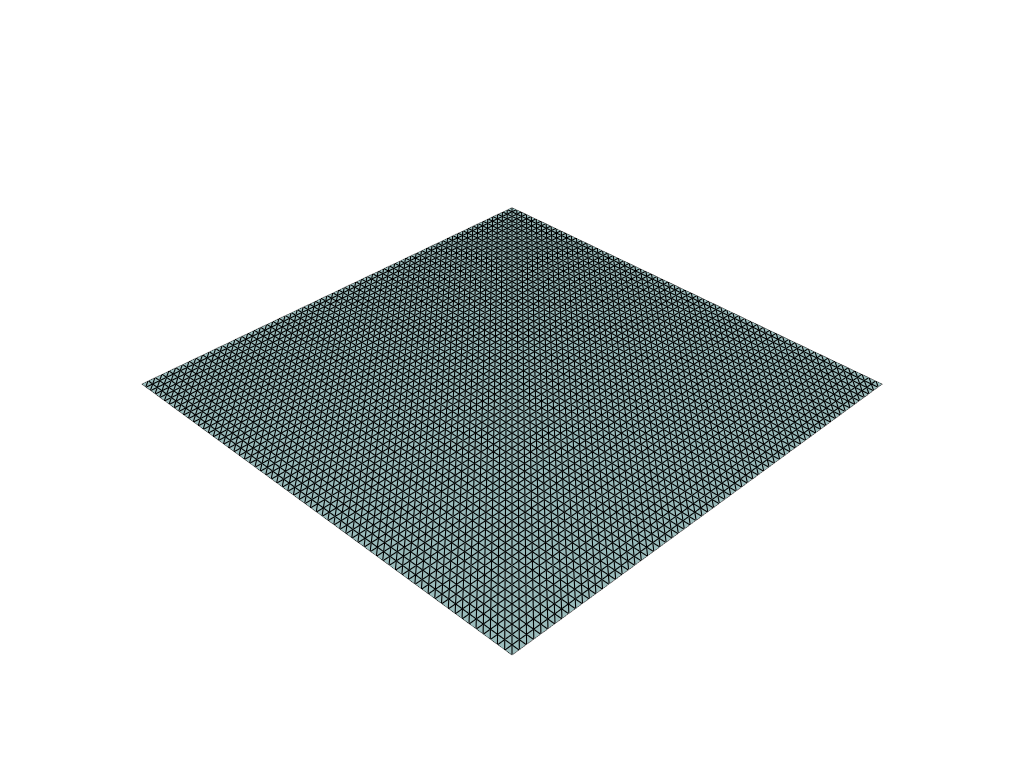

In [7]:
# plot mesh with pyvista
import pyvista as pv
cells, types, x = plot.vtk_mesh(V)
grid = pv.UnstructuredGrid(cells, types, x)
pl = pv.Plotter()
pl.add_mesh(grid, show_edges=True)
pl.show()

## Define variational problem.
The Helmholtz equation can be discretized in the same way for both the
real and complex valued formulation. However, note that we use
`ufl.inner` instead of `ufl.dot` or the ` * ` operator between
the test and trial function, and that the test-function is
**always** the second variable in the operator.
The reason for this is that for complex variational forms,
one requires a sesquilinear two-form, with the inner product being
$(a,b)=\int_\Omega a \cdot \bar{b}~\mathrm{d}x$.

In [8]:
u, v = ufl.TrialFunction(V), ufl.TestFunction(V)
a = ufl.inner(ufl.grad(u), ufl.grad(v)) * ufl.dx - k0**2 * ufl.inner(u, v) * ufl.dx

We solve for plane wave with mixed Dirichlet and Neumann BCs.
We use ufl to manufacture an exact solution and corresponding
boundary conditions.

In [9]:
theta = np.pi / 4
V_exact = functionspace(
    msh, ("Lagrange", deg + 3)
)  # Exact solution should be in a higher order space
u_exact = Function(V_exact, name="u_exact")
u_exact.interpolate(lambda x: A * np.exp(1j * k0 * (np.cos(theta) * x[0] + np.sin(theta) * x[1])))
x = ufl.SpatialCoordinate(msh)
n = ufl.FacetNormal(msh)
g = -ufl.dot(n, ufl.grad(u_exact))
L = -ufl.inner(g, v) * ufl.ds

dofs_D = locate_dofs_geometrical(
    V, lambda x: np.logical_or(np.isclose(x[0], 0), np.isclose(x[1], 0))
)
u_bc = Function(V)
u_bc.interpolate(Expression(u_exact, V.element.interpolation_points))
bcs = [dirichletbc(u_bc, dofs_D)]

/home/annika/miniconda3/envs/fenicsx-env/lib/python3.11/site-packages/dolfinx/fem/function.py:484: ComplexWarning: Casting complex values to real discards the imaginary part
  self._cpp_object.interpolate(np.asarray(u0(x), dtype=self.dtype), cells0)  # type: ignore
